In [1]:
import torch
from dinosaw.linear_probe import get_ramp, gen_sample_mask, do_linear_probe, LinearProbeResult
from dinosaw.helpers import ModelTypes, model_names, get_models, get_features
from dinosaw.utils import do_2D_pca

import numpy as np
from PIL import Image

import matplotlib.pyplot as plt

SEED = 100001
torch.manual_seed(SEED)
np.random.seed(SEED)

half = False
DEVICE = 'cuda:1'

flash attention installed


In [2]:
SF = 1

# img_fname = "micro/tem.png"
# img_fname = "tests/black_square_518.png"
# img_fname = "tests/default_image_518.png"
# img_fname = "micro/000394.jpg"
img_fname = "labradors.png"
# img_fname = "tests/z_c_w.png"
# img_fname = "micro/NMC_2D_less_wide_crop.png"
_img = Image.open(f"../../images/{img_fname}").convert("RGB")
# _img = _img.rotate(90, expand=True)
_img = _img.resize((int(SF * _img.width), int(SF * _img.height)), Image.LANCZOS)

In [3]:
enabled_models: tuple[ModelTypes, ...] = (
    'dv2_b', 'dvt', 'alibi_dv2_cb'
)
models = get_models(enabled_models, "../../trained_models", DEVICE, half)

results: dict[ModelTypes, LinearProbeResult] = {}
feats_reduced: dict[str, np.ndarray] = {}


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [4]:
ramp_type = 'lr'
chosen_vis_model = 'dv2_b'

In [5]:
for model_key in enabled_models:
    model = models[model_key]
    feats = get_features(model, _img, True, False, device=DEVICE)
    probe_res = do_linear_probe(feats, ramp_type, probe_by_channel=True, mask_cutoff_frac=0.8)

    results[model_key] = probe_res
    feats_reduced[model_key] = do_2D_pca(feats.transpose((2, 0, 1)), 3, pre_norm='std', post_norm='minmax')

torch.Size([1, 3504, 768])
torch.Size([1, 3504, 384])
torch.Size([1, 3504, 384])


In [6]:
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection

def add_red_square_overlay(ax: plt.Axes, mask: np.ndarray, sf_h: float, sf_w: int) -> None:
    patches: list[Rectangle] = []
    y_inds, x_inds  = np.nonzero(mask)
    for x, y in zip(x_inds, y_inds):
        rect = Rectangle((x - sf_w / 2, y - sf_h / 2), sf_w, sf_h)
        patches.append(rect)
    pc = PatchCollection(patches, color='red', facecolor='none')
    ax.add_collection(pc)


def set_axes_off(ax: plt.Axes):
    ax.set_xticks([])
    ax.set_yticks([])

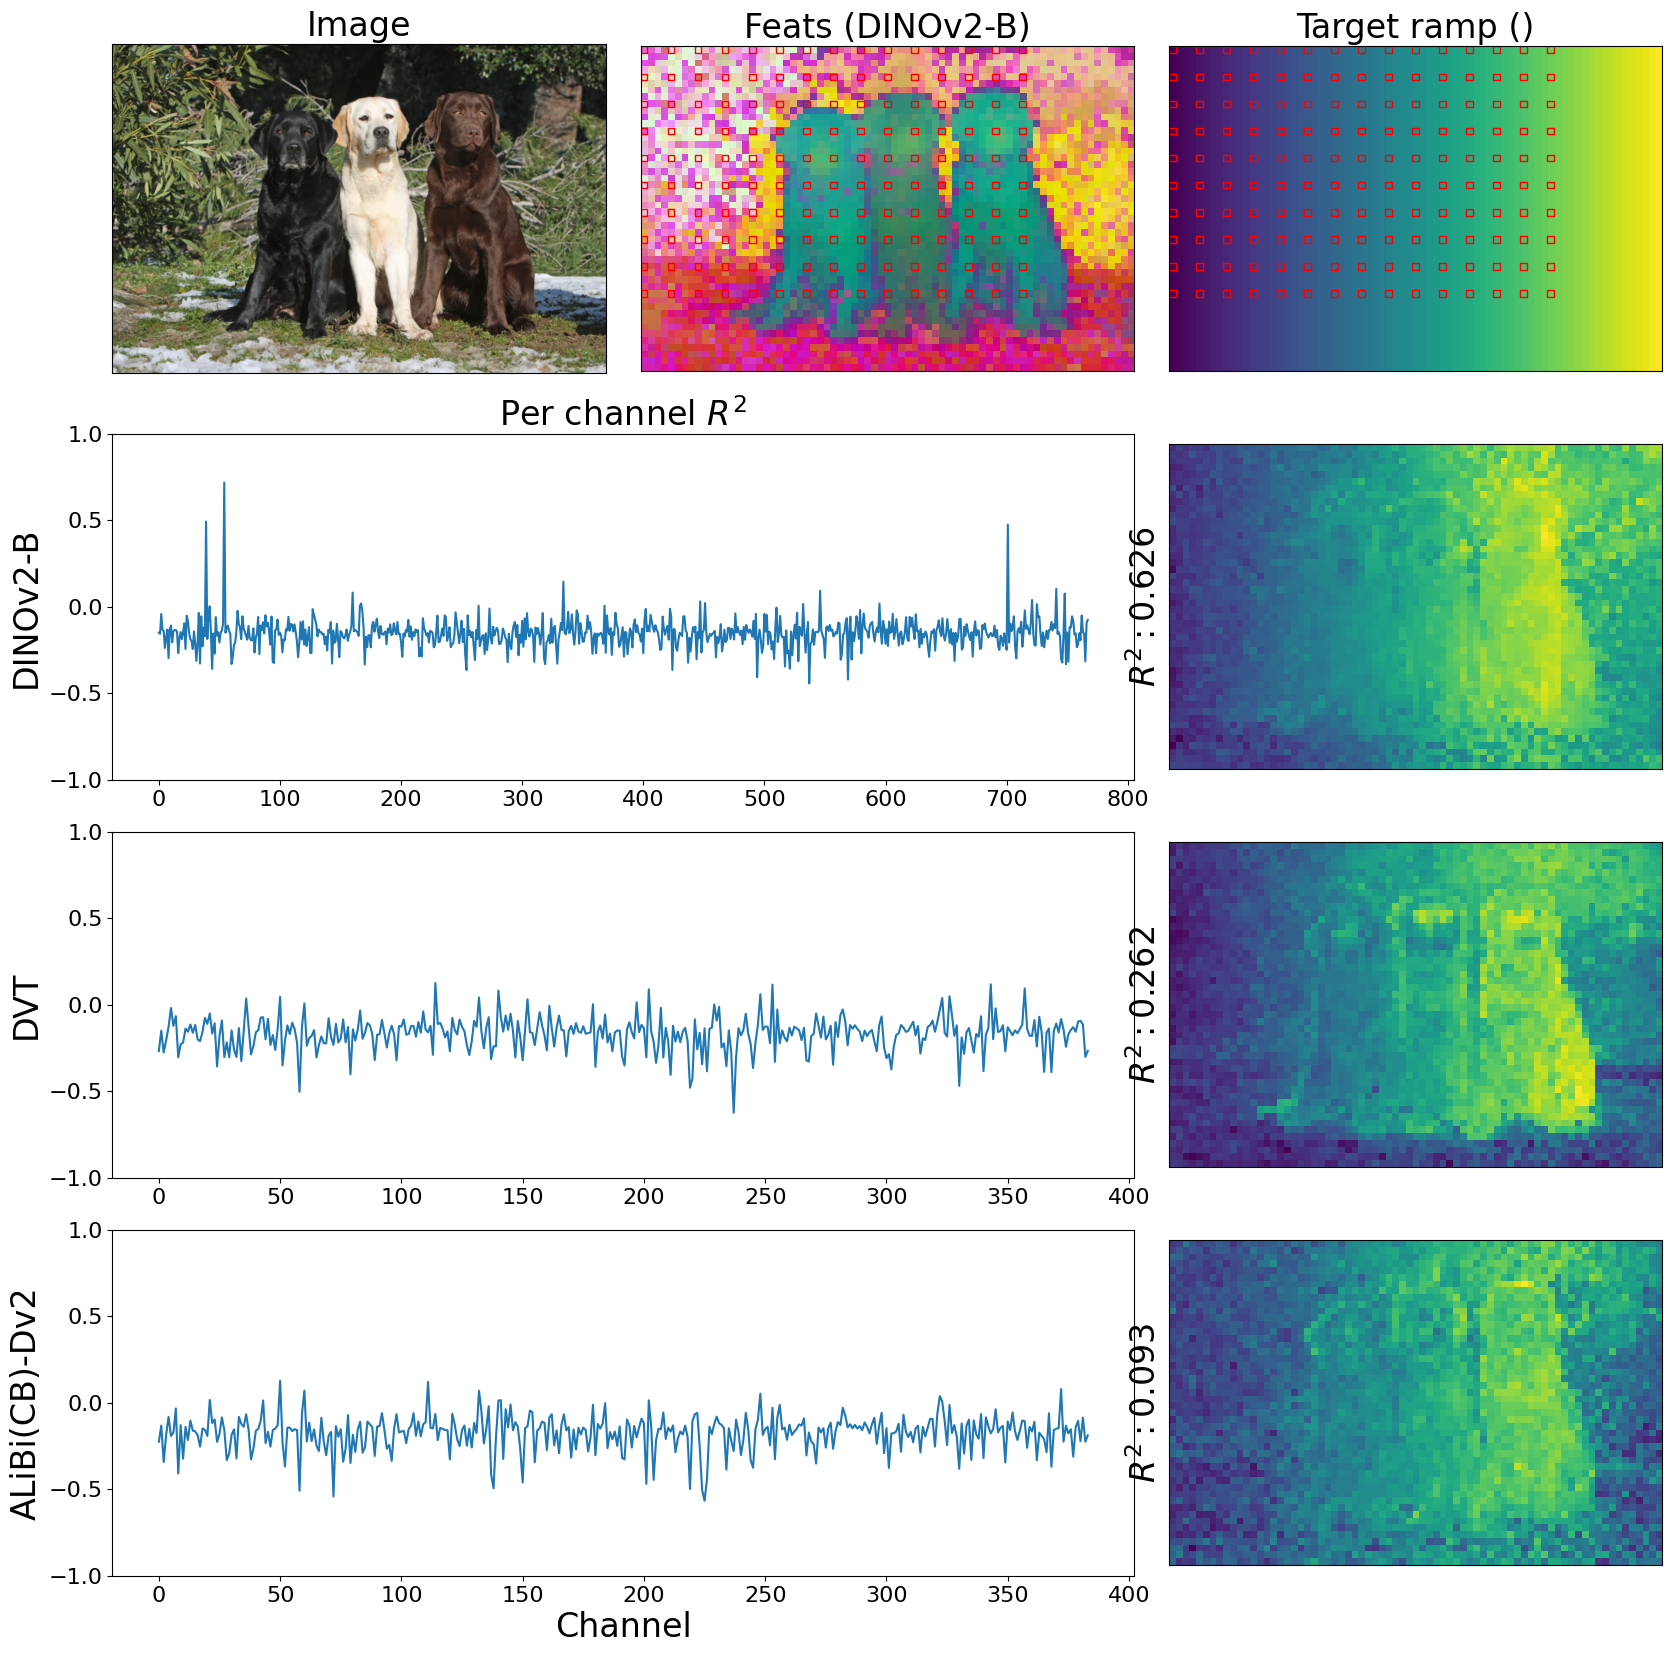

In [8]:
# %%capture
FS = 24
S = 14

fig = plt.figure(figsize=(20, 20))
gs = GridSpec(1 + len(enabled_models), 3, wspace=0.07, hspace=0.15, width_ratios=[1, 1, 1])


img_ax = fig.add_subplot(gs[0,0])
img_ax.imshow(_img)
set_axes_off(img_ax)
img_ax.set_title("Image", fontsize=FS)

pca_ax = fig.add_subplot(gs[0, 1])
pca_ax.imshow(feats_reduced[chosen_vis_model])
set_axes_off(pca_ax)
pca_ax.set_title(f"Feats ({model_names[chosen_vis_model]})", fontsize=FS)


h ,w = (_img.height // S, _img.width // S)
ramp = get_ramp(ramp_type, h, w)
mask = gen_sample_mask((h, w), ramp_type, cutoff_frac=0.8)

ramp_ax = fig.add_subplot(gs[0, 2])
ramp_ax.imshow(ramp)
set_axes_off(ramp_ax)
ramp_ax.set_title("Target ramp ()", fontsize=FS)

add_red_square_overlay(pca_ax, mask, 1,  1)
add_red_square_overlay(ramp_ax, mask, 1,  1)


colors = {'dv2': ''}

for i, model_key in enumerate(enabled_models):
    probe_res = results[model_key]

    scores_ax = fig.add_subplot(gs[i + 1, 0:2])
    scores_ax.set_ylabel(f"{model_names[model_key]}", fontsize=FS)
    scores_ax.plot(probe_res['per_channel_scores'])
    scores_ax.set_ylim(-1, 1)
    scores_ax.tick_params(axis='both', which='major', labelsize=FS - 8)

    if i == 0:
        scores_ax.set_title('Per channel ' +"$R^{2}$", fontsize=FS)
    if i == len(enabled_models) - 1:
        scores_ax.set_xlabel('Channel', fontsize=FS)
        # scores_ax.set_ylabel("$R^{2}:$")

    pred_ax = fig.add_subplot(gs[i + 1, 2])
    pred_ax.imshow(probe_res['stack_pred'])
    pred_ax.set_ylabel(r"$R^{2}: $" + f"{probe_res['stack_r_squared']:.3f}", fontsize=FS)
    set_axes_off(pred_ax)
